# Airspace Congestion Prediction in German Airspace

This project predicts airspace congestion using ADS-B aircraft trajectory data.

### Project configuration

Country: Germany  
Model: Logistic Regression  
Spatial resolution: 0.5° × 0.5° airspace grid  
Temporal resolution: 10-minute intervals  

### Objective

Predict whether a region of German airspace becomes congested based on aircraft traffic patterns.

### Data Source

ADS-B trajectory data from the OpenSky Network.

In [2]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.cluster import KMeans

In [3]:
# Project Parameters
# Geographic boundaries for Germany
GERMANY_LAT_MIN = 47
GERMANY_LAT_MAX = 55
GERMANY_LON_MIN = 5
GERMANY_LON_MAX = 15

# Airspace grid size
GRID_SIZE = 0.5   # degrees

# Time window
TIME_WINDOW = "10min"

# Congestion definition
CONGESTION_THRESHOLD = 12

print("Project parameters loaded")

Project parameters loaded


In [4]:
# Data upload
raw_data = pd.read_csv('../Data/states_2022-06-27-14.csv/states_2022-06-27-14.csv')
raw_data.shape

(3438067, 16)

In [5]:
raw_data.head()

,time,icao24,lat,lon,velocity,heading,vertrate,callsign,onground,alert,spi,squawk,baroaltitude,geoaltitude,lastposupdate,lastcontact
0,1656338400,4d03c6,48.406879,10.712104,200.881654,355.004837,0.32512,NATO02,False,False,False,7410.0,8846.82,9288.78,1.656338e+09,1.656338e+09
1,1656338400,4070e1,54.951965,-4.733653,229.571752,224.001284,7.15264,EXS43DY,False,False,False,2163.0,8542.02,8602.98,1.656338e+09,1.656338e+09
2,1656338400,400fe2,55.090897,-2.791174,224.292864,335.904079,0.32512,EZY764Z,False,False,False,7664.0,11590.02,11711.94,1.656338e+09,1.656338e+09
3,1656338400,407ac6,50.132812,8.160601,219.548884,292.599210,0.00000,TOM2WK,False,False,False,3554.0,11582.40,11955.78,1.656338e+09,1.656338e+09
4,1656338400,4bb1e5,53.671097,-5.179112,223.068281,273.040567,0.00000,THY6057,False,False,False,3577.0,11582.40,11757.66,1.656338e+09,1.656338e+09


In [6]:
raw_data.columns

Index(['time', 'icao24', 'lat', 'lon', 'velocity', 'heading', 'vertrate',
       'callsign', 'onground', 'alert', 'spi', 'squawk', 'baroaltitude',
       'geoaltitude', 'lastposupdate', 'lastcontact'],
      dtype='object')

In [7]:
raw_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3438067 entries, 0 to 3438066
Data columns (total 16 columns):
 #   Column         Dtype  
---  ------         -----  
 0   time           int64  
 1   icao24         object 
 2   lat            float64
 3   lon            float64
 4   velocity       float64
 5   heading        float64
 6   vertrate       float64
 7   callsign       object 
 8   onground       bool   
 9   alert          bool   
 10  spi            bool   
 11  squawk         float64
 12  baroaltitude   float64
 13  geoaltitude    float64
 14  lastposupdate  float64
 15  lastcontact    float64
dtypes: bool(3), float64(10), int64(1), object(2)
memory usage: 350.8+ MB


In [8]:
# Remove rows without coordinates
raw_data = raw_data.dropna(subset=["lat", "lon"])
raw_data.shape

(3189372, 16)

In [9]:
# Filter to the German airspace
data_cleaning = raw_data[
    (raw_data["lat"] >= GERMANY_LAT_MIN) &
    (raw_data["lat"] <= GERMANY_LAT_MAX) &
    (raw_data["lon"] >= GERMANY_LON_MIN) &
    (raw_data["lon"] <= GERMANY_LON_MAX)
]

data_cleaning.shape

(192568, 16)

In [10]:
# Removing aircraft that is on ground
data_cleaning = data_cleaning[data_cleaning["onground"] == False].copy()

In [11]:
# Convert time to data time
data_cleaning["time"] = pd.to_datetime(data_cleaning["time"], unit="s")

In [12]:
# Create 10-minute time window
data_cleaning["time_window"] = data_cleaning["time"].dt.floor(TIME_WINDOW)

In [13]:
# Create airspace grid cells
data_cleaning["lat_cell"] = np.floor(data_cleaning["lat"] / GRID_SIZE) * GRID_SIZE
data_cleaning["lon_cell"] = np.floor(data_cleaning["lon"] / GRID_SIZE) * GRID_SIZE

In [14]:
# Create a grid cell ID for better interpretation
data_cleaning["grid_cell"] = (
    data_cleaning["lat_cell"].astype(str) + "_" +
    data_cleaning["lon_cell"].astype(str)
)

In [15]:
# Aggregate traffic by time window and grid cell
traffic_data = data_cleaning.groupby(
    ["time_window", "grid_cell", "lat_cell", "lon_cell"]
).agg(
    aircraft_count=("icao24", "nunique"),
    avg_velocity=("velocity", "mean"),
    avg_altitude=("baroaltitude", "mean")
).reset_index()

In [16]:
# Create the congestion label
traffic_data["congestion"] = (
    traffic_data["aircraft_count"] >= CONGESTION_THRESHOLD
).astype(int)
traffic_data.head(5)


,time_window,grid_cell,lat_cell,lon_cell,aircraft_count,avg_velocity,avg_altitude,congestion
0,2022-06-27 14:00:00,47.0_10.0,47.0,10.0,5,233.391251,10152.320930,0
1,2022-06-27 14:00:00,47.0_10.5,47.0,10.5,6,230.962005,11136.412286,0
2,2022-06-27 14:00:00,47.0_11.0,47.0,11.0,7,232.295238,10730.002737,0
3,2022-06-27 14:00:00,47.0_11.5,47.0,11.5,5,220.414080,9915.676190,0
4,2022-06-27 14:00:00,47.0_12.0,47.0,12.0,3,165.939251,7538.008800,0


I've converted ADS-B trajectory data to a clean dataframe in which each observation is a grid cell (Regional space) for a specific time window of 10 minutes. This is extremely useful for ATM because this same practice can be applied to multiple complex problems such as Airspace Congestion, Redirection of Aircrafts, Delay prediction, etc.

In [17]:
# How many regions are congested
traffic_data["congestion"].value_counts()

congestion
0    1623
1     214
Name: count, dtype: int64

In [18]:
# Proportion of congested regions
traffic_data["congestion"].value_counts(normalize=True)

congestion
0    0.883506
1    0.116494
Name: proportion, dtype: float64

As stated above the dataset is basically clean, because in real life ATM seeks to ensure that a specific region is always under capacity to avoid any chaos, that's why the dataset shows that most of the regions are not congested. 

In [19]:
# Features and target
X = traffic_data[["aircraft_count", "avg_velocity", "avg_altitude"]]
y = traffic_data["congestion"]

In [20]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
# Is worth to highlight that because of the fact that our dataset demonstrates a high degree of imbalance our test dataset might accidentally 
# only contains 0s. Stratify allows us to have the same proportion in the datasets.

In [21]:
# Train the model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [22]:
# Predictions
y_pred = model.predict(X_test)

In [23]:
# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 1.0

Confusion Matrix:
[[325   0]
 [  0  43]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       325
           1       1.00      1.00      1.00        43

    accuracy                           1.00       368
   macro avg       1.00      1.00      1.00       368
weighted avg       1.00      1.00      1.00       368



The result was that the model predicted 100% of the test data correctly because the congestion label was created using the same aircraft count value that was included as an input feature. This basically means that the model was learning a rule already defined in the data. This was overseen since the beginning, the main goal of this project was to demonstrate how a data science flow is applied to real aviation data.

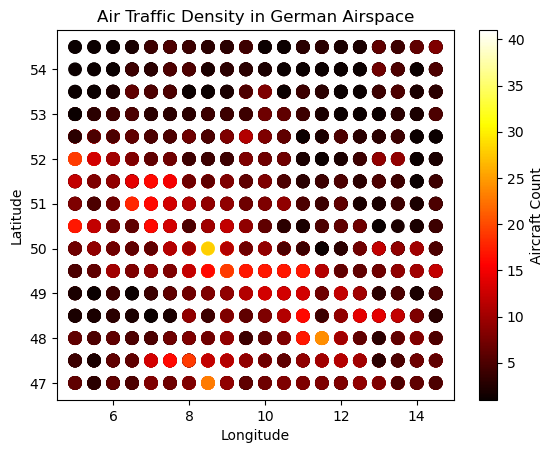

In [40]:
plt.scatter(
    traffic_data['lon_cell'],
    traffic_data['lat_cell'],
    c=traffic_data['aircraft_count'],
    cmap='hot',
    s=80
)
plt.colorbar(label="Aircraft Count")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Air Traffic Density in German Airspace")
plt.show()

This heatmap displays the spatial distribution of air traffic across German airspace. Each point represents a grid cell of approximately 50 km × 50 km. 

In [42]:
# Average aircraft count for each longitude grid cell.
traffic_data.groupby("lon_cell")["aircraft_count"].mean()

lon_cell
5.0     6.707317
5.5     5.976471
6.0     6.076923
6.5     6.252747
7.0     6.663043
7.5     6.553191
8.0     7.127660
8.5     9.319149
9.0     8.258065
9.5     6.957895
10.0    6.978947
10.5    6.684783
11.0    6.697917
11.5    6.000000
12.0    5.757895
12.5    5.348315
13.0    5.195652
13.5    5.280899
14.0    4.880435
14.5    4.329670
Name: aircraft_count, dtype: float64

As displayed in the heatmap central Germany is the most congested region in the country. This region corresponds to major European flight corridors and the Frankfurt area, one of the busiest aviation hubs in Europe.